In [1]:
from io import StringIO
import numpy as np

data_shape = "2D"

if data_shape == "2D":
    from phylomodel_models import ParentPredictor
else:
    from phylomodel_models_3d import ParentPredictor


from dataset_prep_aux_fns_proto import *
    
import matplotlib.pyplot as plt
from networkx.drawing.nx_pydot import graphviz_layout
import torch.nn as nn
import pickle as pkl

from tqdm import tqdm


def greedy_phylo_tree_bottom_up(P):

    n = P.shape[0]
    A = np.zeros((n, n), dtype=int)

    P[0] = 0.0
    
    root = 0
    parents = {root: None}
    parent_count = {}
    assigned_children = {root: []}

    n_int_nodes = P.shape[1]
    leaf_nodes = list(range(n_int_nodes, n))

    used = set(leaf_nodes)

    # assert (np.tril(P, k = -1) == P).all()

    for u in range(1, n):

        probs = [(float(P[u, v]), v) for v in range(n_int_nodes) if v not in used and P[u,v] > 0 and u!=v]            
        probs.sort(reverse=True)

        parent_candidate = probs[0][1]

        if parent_candidate not in parent_count.keys():
            parent_count[parent_candidate] = 1
            parents[u] = parent_candidate
            assigned_children[parent_candidate] = [u]
            A[u, parent_candidate] = 1
        
        elif parent_count[parent_candidate] < 2:
            parent_count[parent_candidate] += 1
            parents[u] = parent_candidate
            assigned_children[parent_candidate].append(u)
            used.add(parent_candidate)
            A[u, parent_candidate] = 1
        
    return A

def will_create_cycle(adj, u, v):

    n = adj.shape[0]

    # DFS starting from v to see if we can reach u
    visited = set()
    stack = [v]

    while stack:
        node = stack.pop()
        if node == u:
            return True  # cycle detected
        if node not in visited:
            visited.add(node)
            neighbors = np.where(adj[:, node] != 0)[0]  # outgoing edges
            stack.extend(neighbors)

    return False


def to_newick(G, node):
    children = list(G.successors(node))  # for directed graph
    if not children:
        # Leaf: just return name with branch length if available
        if G.in_edges(node):
            parent = list(G.predecessors(node))[0]
            return f"{node}:{G[parent][node].get('weight', 1.0)}"
        else:
            return node  # root leaf (edge case)
    else:
        # Internal node: recurse over children
        subtrees = [to_newick(G, c) for c in children]
        if G.in_edges(node):
            parent = list(G.predecessors(node))[0]
            return f"({','.join(subtrees)}){node}:{G[parent][node].get('weight', 1.0)}"
        else:
            # Root node (no incoming edge) → no branch length
            return f"({','.join(subtrees)}){node}"



In [36]:
gpu = 1 # str(get_free_gpu())
device = f"cuda:{gpu}" if torch.cuda.is_available() else "cpu"

checkpoint_path = "./fit-PF00004-size-4-15-epochs.pt"
subtree_size = 4

checkpoint = torch.load(checkpoint_path, weights_only=True)

model = ParentPredictor(**checkpoint["model_hparams"]).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

msa_transf, alphabet = esm.pretrained.esm_msa1b_t12_100M_UR50S()
msa_transf = msa_transf.to(device)
batch_converter = alphabet.get_batch_converter()
msa_transf.eval()

with open("../data/families_under_200_over_50.pkl","rb") as f:

    all_families_init = pkl.load(f)

all_families = []

for family in all_families_init:

    if os.path.exists(f"../data/msa-seed-simulations/MSA-1b/{family}/init-seq-0/logits-proposal/static-context/10/{family}-1.fasta"):
        all_families.append(family)


np.random.seed(42)

train_split = 0.9
train_size = int(np.ceil(train_split * len(all_families)))

train_families_ind = np.random.choice(range(len(all_families)), train_size, replace = False)
train_families = [all_families[ind] for ind in train_families_ind]

test_families_ind = list(set(range(len(all_families))) - set(train_families_ind))
test_families = [all_families[ind] for ind in test_families_ind]

# test_msas_folder = f"../data/msa-seed-simulations/MSA-1b/"
# test_msa_paths = [os.path.join(test_msas_folder, family, f"init-seq-0/logits-proposal/static-context/10/{family}-1.fasta") for family in test_families]

# test_trees_folder = f"../data/seed-trees/"
# test_tree_paths = [os.path.join(test_msas_folder, f"{family}_seed.newick") for family in test_families]

# train_msas_folder = f"../data/msa-seed-simulations/MSA-1b/"
# train_msa_paths = [os.path.join(train_msas_folder, family, f"init-seq-0/logits-proposal/static-context/10/{family}-1.fasta") for family in train_families]

# train_trees_folder = f"../data/seed-trees/"
# train_tree_paths = [os.path.join(train_trees_folder, f"{family}_seed.newick") for family in train_families]

# test_msas_folder = f"../data/submsa-seed-simulations-equal-size/{subtree_size}/"
# test_msa_paths = [os.path.join(test_msas_folder, family, "submsa-1.fasta") for family in test_families]

# test_trees_folder = f"../data/msa-seed-simulations-subtrees-equal-size/{subtree_size}/"
# test_tree_paths = [os.path.join(test_msas_folder, family, "subtree-1.newick") for family in test_families]

# train_msas_folder = f"../data/submsa-seed-simulations-equal-size/{subtree_size}/"
# train_msa_paths = [os.path.join(train_msas_folder, family, "submsa-1.fasta") for family in train_families]

# train_trees_folder = f"../data/msa-seed-simulations-subtrees-equal-size/{subtree_size}/"
# train_tree_paths = [os.path.join(train_trees_folder, family, "subtree-1.newick") for family in train_families]

test_msas_folder = f"../data/submsa-seed-simulations-equal-size/4/test/PF00004/"
test_msa_paths = sorted(os.listdir(test_msas_folder))
test_msa_paths = [os.path.join(test_msas_folder, test_msa_path) for test_msa_path in test_msa_paths]

test_trees_folder = f"../data/msa-seed-simulations-subtrees-equal-size/4/test/PF00004/"
test_tree_paths = sorted(os.listdir(test_trees_folder))
test_tree_paths = [os.path.join(test_trees_folder, test_tree_path) for test_tree_path in test_tree_paths]

train_msas_folder = f"../data/submsa-seed-simulations-equal-size/4/train/PF00004/"
train_msa_paths = sorted(os.listdir(train_msas_folder))
train_msa_paths = [os.path.join(train_msas_folder, train_msa_path) for train_msa_path in train_msa_paths]

train_trees_folder = f"../data/msa-seed-simulations-subtrees-equal-size/4/train/PF00004/"
train_tree_paths = sorted(os.listdir(train_trees_folder))
train_tree_paths = [os.path.join(train_trees_folder, train_tree_paths) for train_tree_paths in train_tree_paths]

inferred_trees = {}
test_mats = []

for i,input_MSA_path in tqdm(enumerate(test_msa_paths)):

    input_MSA = read_msa(input_MSA_path)
    tree_id = int(input_MSA_path.split(".")[-2].split('-')[-1])
    # tree_id = test_families[i]

    n_int_nodes = len(input_MSA) - 1
    total_nodes = 2 * len(input_MSA) - 1
    leaf_nodes = len(input_MSA)


    input_MSA_order = {seq[0]:i for i,seq in enumerate(input_MSA)}

    leaf_embeddings = prepare_initial_leaf_embeddings([input_MSA_path], Large_D=768, model = msa_transf, batch_converter= batch_converter, use_transf=True, device = device)[0]
    int_node_embeddings = prepare_initial_int_node_embeddings(input_MSA_path, input_MSA_order, Large_D=768, leaf_embeddings=leaf_embeddings, delete_init_tree = True, fam = family)

    # X = prepare_initial_leaf_embeddings([input_MSA_path], Large_D = 768, model = msa_transf, batch_converter = batch_converter, device = device, use_transf = False, alphabet = alphabet)[0]
    X = torch.concat((int_node_embeddings, leaf_embeddings), dim=0).to(device)

    with torch.no_grad():
        soft_adj_mat = model(X, attn_mask = None).squeeze(-1)[...,:n_int_nodes]
        size = soft_adj_mat.shape[0]
        mask = torch.triu(torch.ones(size, size), diagonal=0).bool()[...,:n_int_nodes].to(device)
        soft_adj_mat = soft_adj_mat.masked_fill(mask, float('-inf'))
        # soft_adj_mat = nn.Softmax(dim = 0)(soft_adj_mat).cpu().numpy()
        soft_adj_mat = nn.Softmax(dim = 1)(soft_adj_mat).cpu().numpy()
        # print(soft_adj_mat)
        
    test_mats.append(soft_adj_mat)

    hard_adj_mat = greedy_phylo_tree_bottom_up(soft_adj_mat.copy())
    hard_adj_mat = np.transpose(hard_adj_mat)

    tree_graph = nx.from_numpy_array(hard_adj_mat, create_using=nx.DiGraph)

    labels = list(map(str,range(n_int_nodes))) + list(input_MSA_order.keys())
    mapping = {i: labels[i] for i in range(len(labels))}
    tree_graph = nx.relabel_nodes(tree_graph, mapping)

    # cycles = list(nx.simple_cycles(tree_graph))
    # print("Cycles found:", cycles)

    # cycle_nodes = set(n for c in cycles for n in c)
    # node_colors = ["red" if n in cycle_nodes else "lightblue" for n in tree_graph.nodes]

    # pos = graphviz_layout(tree_graph, prog="dot")
    # plt.figure(figsize=(30, 30))
    # nx.draw(tree_graph, pos,
    #         with_labels=True,
    #         node_color=node_colors,
    #         node_size=500,
    #         arrowsize=20,
    #         font_size=8)

    # plt.title("Cycles highlighted in red")
    # plt.show()

    newick_str = to_newick(tree_graph, "0") + ";"
    tree = Tree(newick=newick_str, format = 1)
    inferred_trees[tree_id] = tree

100%|██████████| 1/1 [00:00<00:00, 54.89it/s]
2000it [01:02, 32.00it/s]


In [40]:
import os

subtrees_folder = "../data/submsa-seed-simulations-equal-size/4/PF00005/"
repeats = []
submsas = set()
for file in os.listdir(subtrees_folder):

    submsa = read_msa(os.path.join(subtrees_folder, file))
    l_before_add = len(submsas)
    submsas.add(tuple(sorted([x[0] for x in submsa])))
    l_after_add = len(submsas)

    if l_before_add == l_after_add:
        repeats.append(submsa)

In [37]:
from ete3 import Tree

tree_rfs = []
dataset = "test"

for id in tqdm(list(inferred_trees.keys())):
    
    MSA_file_path = f"../data/submsa-seed-simulations-equal-size/4/{dataset}/PF00004/submsa-{id}.fasta"
    # MSA_file_path = f"../data/submsa-seed-simulations-equal-size/{subtree_size}/{id}/submsa-1.fasta"
    # MSA_file_path = f"../data/msa-seed-simulations/MSA-1b/{id}/init-seq-0/logits-proposal/static-context/10/{id}-1.fasta"

    temp_tree_file = f"{MSA_file_path}-temp.newick"

    subprocess.run(["rapidnj",MSA_file_path,"-i","fa","-x",temp_tree_file])

    init_tree = Tree(temp_tree_file, format=1)
    init_tree.set_outgroup(init_tree.get_midpoint_outgroup())

    for node in init_tree.get_leaves():
        node.name = node.name.replace("'","")
    
    subprocess.run(['rm', temp_tree_file])

    inferred_tree = inferred_trees[id].copy()
    # inferred_tree.unroot()
    # inferred_tree.set_outgroup(inferred_tree.get_midpoint_outgroup())

    true_tree = Tree(f"../data/msa-seed-simulations-subtrees-equal-size/4/{dataset}/PF00004/subtree-{id}.newick", format = 1)
    # true_tree = Tree(f"../data/msa-seed-simulations-subtrees-equal-size/{subtree_size}/{id}/subtree-1.newick", format = 1)
    # true_tree = Tree(f"../data/seed-trees/{id}_seed.newick", format = 1)
    # true_tree.set_outgroup(true_tree.get_midpoint_outgroup())
    # true_tree.unroot()

    tree_rfs.append({"subtree_id":id,
                     "inferred-true-rf": inferred_tree.compare(true_tree)["norm_rf"],
                    "inferred-init-rf": inferred_tree.compare(init_tree,)["norm_rf"],
                    "init-true-rf": init_tree.compare(true_tree)["norm_rf"]
                    })
    
    if inferred_tree.compare(true_tree)["norm_rf"] == "NA":
        raise Exception("Stop")

tree_rfs = pd.DataFrame(tree_rfs)

100%|██████████| 2000/2000 [00:20<00:00, 97.63it/s] 0% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% % 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% % 0.00% 0.00% 0.00% % 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.00% 0.0

In [38]:
tree_rfs["inferred-true-rf"].mean()

np.float64(0.2025)

In [30]:
tree_rfs.to_csv("tree-rfs-under-200-size-4-frob-mask-pp-50-epochs.tsv",sep = "\t")

In [13]:
import pickle as pkl

with open("../data/processed-train-test-data/train_test_sets_leaves_PF00004_size_4_no_leak_pp.pkl","rb") as f:
   data = pkl.load(f)

In [14]:
# X_train = data[0]
# X_test = data[1]
# y_train_bl = data[2]
# y_test_bl = data[3]
# y_train_pc = data[4]
# y_test_pc = data[5]

X_train = data["X_train"]
X_test = data["X_test"]
y_train_bl = data["y_train_bl"]
y_test_bl = data["y_test_bl"]
y_train_pc = data["y_train_pc"]
y_test_pc = data["y_test_pc"]

In [15]:
X_train[0].shape

torch.Size([7, 768])

In [62]:
count = 0

for x in y_train_pc:

    row_ids = torch.arange(len(x))
    
    diff = row_ids - x

    if bool((diff > 0).all()):
        count += 1
        continue
    else:
        raise Exception("Not lower triangular")


In [7]:
import pandas as pd

tree_rfs = pd.read_csv("../results/under-200/tree-rfs-under-200-pp.tsv", delimiter = "\t")

In [10]:
tree_rfs = tree_rfs.iloc[:,1:]

In [12]:
tree_rfs["inferred-true-rf"].mean()

np.float64(0.8783136940186654)

## Root Distance and Branch Length Method

In [2]:
from io import StringIO
import numpy as np
from phylomodel_models_root_distance import MainPhyloModel
from dataset_prep_aux_fns import *
import matplotlib.pyplot as plt
from networkx.drawing.nx_pydot import graphviz_layout
import torch.nn as nn
import pickle as pkl

from tqdm import tqdm

def adj_mat_from_distances(branch_lengths, root_distances):

    n_nodes = len(branch_lengths)
    n_int_nodes = int((len(branch_lengths) + 1)/2 - 1)
    n_leaf_nodes = n_int_nodes + 1

    A = np.zeros((n_nodes, n_nodes))

    queue = [0]
    used = set([0])

    total_leaf_count = 0

    while queue:

        cur_node = queue.pop(0)

        if cur_node > n_int_nodes - 1:
            continue

        diff =  root_distances - branch_lengths - root_distances[cur_node]
        diff_ind_order = np.argsort(diff)

        n_children = 0
        leaf_children = 0

        for i in diff_ind_order:

            if len(queue) == 1 and leaf_children == 1 and i > n_int_nodes - 1 and total_leaf_count < n_leaf_nodes - 1:
                continue

            if n_children == 2:
                break
            
            if i not in used:

                A[cur_node, i] = branch_lengths[i]
                queue.append(i)
                used.add(i)
                n_children += 1

                if i > n_int_nodes - 1:
                    leaf_children += 1
                    total_leaf_count += 1

    return A

def prepare_initial_leaf_embeddings(msa, Large_D = 1000, model = None, batch_converter = None, device = None):

    torch.cuda.empty_cache()

    _, _, tokens = batch_converter([msa])
    tokens = tokens.to(device)

    with torch.no_grad():
        embeddings = model(tokens, need_head_weights = False, return_contacts = False, repr_layers = [12])["representations"][12][0]
        embeddings = embeddings.mean(dim=1)
        R, H = embeddings.shape
        padding_tensor = torch.zeros((R, Large_D - H)).to(device)
        embeddings = torch.concat((embeddings, padding_tensor), dim=1)

        del padding_tensor, tokens
        torch.cuda.empty_cache()

    return embeddings

def to_newick(G, node):
    children = list(G.successors(node))  # for directed graph
    if not children:
        # Leaf: just return name with branch length if available
        if G.in_edges(node):
            parent = list(G.predecessors(node))[0]
            return f"{node}:{G[parent][node].get('weight', 1.0)}"
        else:
            return node  # root leaf (edge case)
    else:
        # Internal node: recurse over children
        subtrees = [to_newick(G, c) for c in children]
        if G.in_edges(node):
            parent = list(G.predecessors(node))[0]
            return f"({','.join(subtrees)}){node}:{G[parent][node].get('weight', 1.0)}"
        else:
            # Root node (no incoming edge) → no branch length
            return f"({','.join(subtrees)}){node}"






    

#### Training and Inference on few families, many subtrees

In [4]:
gpu = str(get_free_gpu())
device = f"cuda:{gpu}" if torch.cuda.is_available() else "cpu"
msa_transf, alphabet = esm.pretrained.esm_msa1b_t12_100M_UR50S()
msa_transf = msa_transf.to(device)
batch_converter = alphabet.get_batch_converter()
msa_transf.eval()

checkpoint_path = "../models/fit-PF00004-size-50-weighted-sumpos-rd-100-epochs.pt"

checkpoint = torch.load(checkpoint_path, weights_only=False)

model = MainPhyloModel(**checkpoint["model_hparams"]).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

with open("../data/families_under_200_over_10.pkl","rb") as f:

    all_families_init = pkl.load(f)

all_families = []

for family in all_families_init:

    if os.path.exists(f"../data/msa-seed-simulations/MSA-1b/{family}/init-seq-0/logits-proposal/static-context/10/{family}-1.fasta"):
        all_families.append(family)

all_families = ["PF00004"]

np.random.seed(42)

inferred_trees = {}

for fam in all_families:

    data_ids = list(range(1,20000))

    train_split = 0.9
    train_size = int(np.ceil(train_split * len(data_ids)))

    train_ids_ind = np.random.choice(range(len(data_ids)), train_size, replace = False)
    train_ids = [data_ids[ind] for ind in train_ids_ind]

    test_ids_ind = list(set(range(len(data_ids))) - set(train_ids_ind))
    test_ids = [data_ids[ind] for ind in test_ids_ind]

    # all_families = all_families[:100]

    # train_ids= ["4745"]

    pred_rd = []
    pred_bl = []

    for id in tqdm(test_ids):

        # input_MSA_path = f"../data/simulated_msas_phyloformer/{id}_50_tips.fa"
        input_MSA_path = f"../data/submsa-seed-simulations-equal-size/50/{fam}/submsa-{id}.fasta"
        input_MSA = read_msa(input_MSA_path)

        n_int_nodes = len(input_MSA) - 1
        total_nodes = 2 * len(input_MSA) - 1
        leaf_nodes = len(input_MSA)

        input_MSA_order = {seq[0]:i for i,seq in enumerate(input_MSA)}
        X = prepare_initial_leaf_embeddings(input_MSA, Large_D=768, model = msa_transf, batch_converter = batch_converter, device = device)

        with torch.no_grad():
            branch_lengths, root_distances = model(X, attn_mask = None)
            branch_lengths = branch_lengths.squeeze(-1).cpu().numpy()
            root_distances = root_distances.squeeze(-1).cpu().numpy()
            root_distances[0] = 0.0
            branch_lengths[0] = 0.0
            pred_rd.append(root_distances)
            pred_bl.append(branch_lengths)

        hard_adj_mat = adj_mat_from_distances(branch_lengths, root_distances)
        tree_graph = nx.from_numpy_array(hard_adj_mat, create_using=nx.DiGraph)

        labels = list(map(str,range(n_int_nodes))) + list(input_MSA_order.keys())
        mapping = {i: labels[i] for i in range(len(labels))}
        tree_graph = nx.relabel_nodes(tree_graph, mapping)

        # cycles = list(nx.simple_cycles(tree_graph))
        # print("Cycles found:", cycles)

        # cycle_nodes = set(n for c in cycles for n in c)
        # node_colors = ["red" if n in cycle_nodes else "lightblue" for n in tree_graph.nodes]

        # pos = graphviz_layout(tree_graph, prog="dot")
        # plt.figure(figsize=(30, 30))
        # nx.draw(tree_graph, pos,
        #         with_labels=True,
        #         node_color=node_colors,
        #         node_size=500,
        #         arrowsize=20,
        #         font_size=8)

        # plt.title("Cycles highlighted in red")
        # plt.show()

        # newick_str = to_newick(tree_graph, "0") + ";"

        # handle = StringIO(newick_str)
        # tree = Phylo.read(handle, "newick")
        # Phylo.write(tree, "inferred-tree-test.newick", "newick")
        # Phylo.draw_ascii(tree)
        
        newick_str = to_newick(tree_graph, "0") + ";"
        tree = Tree(newick=newick_str, format = 1)
        inferred_trees[(fam,id)] = tree

100%|██████████| 1999/1999 [05:29<00:00,  6.06it/s]


#### Training and Inference on many families, few subtrees

In [57]:
gpu = str(get_free_gpu())
device = f"cuda:{gpu}" if torch.cuda.is_available() else "cpu"
msa_transf, alphabet = esm.pretrained.esm_msa1b_t12_100M_UR50S()
msa_transf = msa_transf.to(device)
batch_converter = alphabet.get_batch_converter()
msa_transf.eval()

checkpoint_path = "../models/fit-under-200-size-4-10-reps-rd-50-epochs.pt"

checkpoint = torch.load(checkpoint_path, weights_only=False)

model = MainPhyloModel(**checkpoint["model_hparams"]).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

with open("../data/families_under_200_over_50.pkl","rb") as f:

    all_families_init = pkl.load(f)

all_families = []

for family in all_families_init:

    if os.path.exists(f"../data/msa-seed-simulations/MSA-1b/{family}/init-seq-0/logits-proposal/static-context/10/{family}-1.fasta"):
        all_families.append(family)

np.random.seed(42)

# all_families = [x.split('_')[0] for x in os.listdir("../data/simulated_msas_phyloformer/")]
inferred_trees = {}

num_subtrees = 1

train_split = 0.9
train_size = int(np.ceil(train_split * len(all_families)))

train_families_ind = np.random.choice(range(len(all_families)), train_size, replace = False)
train_families = [all_families[ind] for ind in train_families_ind]

test_families_ind = list(set(range(len(all_families))) - set(train_families_ind))
test_families = [all_families[ind] for ind in test_families_ind]

train_fam_reps = []

for family in train_families:
    train_fam_reps += [family] * num_subtrees

ind_reps = list(range(1, num_subtrees + 1)) * len(train_families)

train_ids = [(train_fam_reps[i], ind_reps[i]) for i in range(len(ind_reps))]

test_fam_reps = []

for family in test_families:
    test_fam_reps += [family] * num_subtrees

ind_reps = list(range(1, num_subtrees + 1)) * len(test_families)

test_ids = [(test_fam_reps[i], ind_reps[i]) for i in range(len(ind_reps))]

pred_rd = []
pred_bl = []

for id in tqdm(train_ids):

    input_MSA_path = f"../data/submsa-seed-simulations-equal-size/4/{id[0]}/submsa-{id[1]}.fasta"
    # input_MSA_path = f"../data/simulated_msas_phyloformer/{id[0]}_50_tips.fa"
    input_MSA = read_msa(input_MSA_path)

    n_int_nodes = len(input_MSA) - 1
    total_nodes = 2 * len(input_MSA) - 1
    leaf_nodes = len(input_MSA)

    input_MSA_order = {seq[0]:i for i,seq in enumerate(input_MSA)}
    X = prepare_initial_leaf_embeddings(input_MSA, Large_D=768, model = msa_transf, batch_converter = batch_converter, device = device)

    with torch.no_grad():
        branch_lengths, root_distances = model(X, attn_mask = None)
        branch_lengths = branch_lengths.squeeze(-1).cpu().numpy()
        root_distances = root_distances.squeeze(-1).cpu().numpy()
        root_distances[0] = 0.0
        branch_lengths[0] = 0.0
        pred_rd.append(root_distances)
        pred_bl.append(branch_lengths)

    hard_adj_mat = adj_mat_from_distances(branch_lengths, root_distances)
    tree_graph = nx.from_numpy_array(hard_adj_mat, create_using=nx.DiGraph)

    labels = list(map(str,range(n_int_nodes))) + list(input_MSA_order.keys())
    mapping = {i: labels[i] for i in range(len(labels))}
    tree_graph = nx.relabel_nodes(tree_graph, mapping)

    # cycles = list(nx.simple_cycles(tree_graph))
    # print("Cycles found:", cycles)

    # cycle_nodes = set(n for c in cycles for n in c)
    # node_colors = ["red" if n in cycle_nodes else "lightblue" for n in tree_graph.nodes]

    # pos = graphviz_layout(tree_graph, prog="dot")
    # plt.figure(figsize=(30, 30))
    # nx.draw(tree_graph, pos,
    #         with_labels=True,
    #         node_color=node_colors,
    #         node_size=500,
    #         arrowsize=20,
    #         font_size=8)

    # plt.title("Cycles highlighted in red")
    # plt.show()

    # newick_str = to_newick(tree_graph, "0") + ";"

    # handle = StringIO(newick_str)
    # tree = Phylo.read(handle, "newick")
    # Phylo.write(tree, "inferred-tree-test.newick", "newick")
    # Phylo.draw_ascii(tree)
    
    newick_str = to_newick(tree_graph, "0") + ";"
    tree = Tree(newick=newick_str, format = 1)
    inferred_trees[(id[0],id[1])] = tree

100%|██████████| 4345/4345 [02:15<00:00, 32.00it/s]


In [24]:
len(inferred_trees)

4345

In [5]:
from ete3 import Tree

tree_rfs = []

for fam, id in list(inferred_trees.keys()):

    MSA_file_path = f"../data/submsa-seed-simulations-equal-size/50/{fam}/submsa-{id}.fasta"
    # MSA_file_path = f"../data/simulated_msas_phyloformer/{fam}_50_tips.fa"

    temp_tree_file = f"{MSA_file_path}-temp.newick"

    subprocess.run(["rapidnj",MSA_file_path,"-i","fa","-x",temp_tree_file])

    init_tree = Tree(temp_tree_file, format=1)
    init_tree.set_outgroup(init_tree.get_midpoint_outgroup())

    for node in init_tree.get_leaves():
        node.name = node.name.replace("'","").rstrip()
    
    subprocess.run(['rm', temp_tree_file])

    inferred_tree = inferred_trees[(fam,id)]

    true_tree = Tree(f"../data/msa-seed-simulations-subtrees-equal-size/50/{fam}/subtree-{id}.newick", format = 1)
    # true_tree = Tree(f"../data/simulated_trees_phyloformer/{fam}_50_tips.newick", format = 1)
    # true_tree.set_outgroup(true_tree.get_midpoint_outgroup())

    tree_rfs.append({"family":fam,
                    "subtree_id":id,
                    "inferred-true-rf": inferred_tree.compare(true_tree)["norm_rf"],
                    "inferred-init-rf": inferred_tree.compare(init_tree)["norm_rf"],
                    "init-true-rf": init_tree.compare(true_tree)["norm_rf"]
                })

tree_rfs = pd.DataFrame(tree_rfs)

In [26]:
np.max(tree_rfs["inferred-true-rf"])


np.float64(1.0)

In [8]:
tree_rfs.to_csv("tree-rfs-rd-100-epochs.tsv", sep = "\t", index = False)

In [9]:
import pickle as pkl

# with open("../data/processed-train-test-data/train_test_sets_leaves_PF00004_size_50_rd.pkl","rb") as f:
#    data = pkl.load(f)

with open("../data/processed-train-test-data/train_test_sets_leaves_PF00004_size_50_rd.pkl","rb") as f:
   data = pkl.load(f)

X_train = data[0]
X_test = data[1]
y_train_bl = data[2]
y_test_bl = data[3]
y_train_rd = data[4]
y_test_rd = data[5]

In [13]:
import pickle as pkl

with open("../data/processed-train-test-data/train_test_sets_leaves_PF00004_size_4_no_leak_simple_pp.pkl","rb") as f:
   data = pkl.load(f)

X_train = data["X_train"]
X_test = data["X_test"]
y_train_bl = data["y_train_bl"]
y_test_bl = data["y_test_bl"]
y_train_pc = data["y_train_pc"]
y_test_pc = data["y_test_pc"]

In [24]:
y_test_pc[3]

tensor([-2,  0,  0,  1,  1,  2,  2])

In [1]:
import torch
import esm


In [4]:
model, alphabet = esm.pretrained.esm_msa1b_t12_100M_UR50S()

In [11]:
model.embed_tokens.weight

Parameter containing:
tensor([[ 0.0015,  0.0050, -0.0076,  ..., -0.0561, -0.0256, -0.0512],
        [-0.2673, -0.0990,  0.1875,  ..., -0.1162,  0.0708, -0.2198],
        [-0.2825, -0.1011,  0.1860,  ..., -0.1100,  0.0744, -0.2191],
        ...,
        [ 0.0301, -0.0293,  0.0034,  ..., -0.1205, -0.0119,  0.0238],
        [-0.0172, -0.0340,  0.1136,  ..., -0.2734, -0.0099, -0.0238],
        [-0.0086, -0.0358,  0.0795,  ..., -0.3044,  0.0036, -0.0347]],
       requires_grad=True)

In [53]:
max_diffs_rd = np.array([(abs(pred_rd[i] - y_test_rd[i].numpy())).max().item() for i in range(len(pred_rd))])
max_diffs_bl = np.array([(abs(pred_bl[i] - y_test_bl[i].numpy())).max().item() for i in range(len(pred_bl))])

mean_diffs_rd = np.array([(abs(pred_rd[i] - y_test_rd[i].numpy())).mean().item() for i in range(len(pred_rd))])
mean_diffs_bl = np.array([(abs(pred_bl[i] - y_test_bl[i].numpy())).mean().item() for i in range(len(pred_bl))])

median_diffs_rd = np.array([np.median((abs(pred_rd[i] - y_test_rd[i].numpy()))).item() for i in range(len(pred_rd))])
median_diffs_bl = np.array([np.median((abs(pred_bl[i] - y_test_bl[i].numpy()))).item() for i in range(len(pred_bl))])

argmax_diffs_rd = np.array([np.argmax((abs(pred_rd[i] - y_test_rd[i].numpy()))).item() for i in range(len(pred_rd))])
argmax_diffs_bl = np.array([np.argmax((abs(pred_bl[i] - y_test_bl[i].numpy()))).item() for i in range(len(pred_bl))])

In [57]:
np.median(max_diffs_bl)

np.float64(0.4139277935028076)

In [50]:
argmax_diffs_bl

array([32])

In [40]:
y_train_bl[0][1:].min()

tensor(0.0044)

In [35]:
np.mean(max_diffs_bl)

np.float64(0.45728877293371806)

In [28]:
np.median(pd.Series(torch.concat(y_test_bl).flatten()))

np.float32(0.242326)

In [115]:
max_diffs_bl.mean()

np.float64(0.5249619138589676)

In [20]:
a = [1,2,3]
a.extend([4,5,6])

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns



In [86]:
y1 = torch.concat(y_train_bl).numpy().flatten()
y2 = torch.concat(y_train_rd).numpy().flatten()

y1 = y1[y1 > 0]
y2 = y2[y2 > 0]

y1_sd = np.std(y1)
y2_sd = np.std(y2)

y1_mean = np.mean(y1)
y2_mean = np.mean(y2)

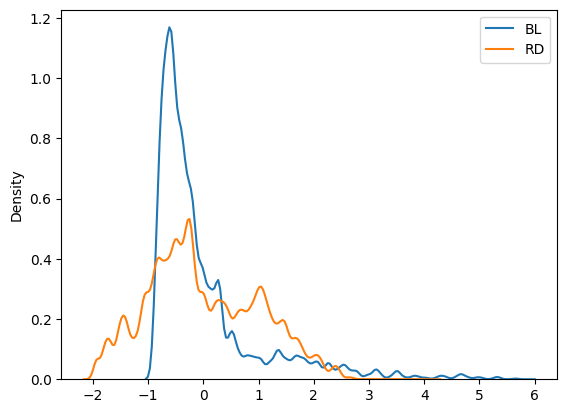

In [87]:
fig, axes = plt.subplots()

log_y1 = np.log10(y1)
log_y2 = np.log10(y2)

# axes.hist(log_y1, np.arange(min(log_y1)-0.5, max(log_y1)+0.5, 0.1), label="log BL")
# axes.hist(log_y2, np.arange(min(log_y2)-0.5, max(log_y2)+0.5, 0.1), label="log RD")
# axes.hist(y1, np.arange(min(y1)-0.5, max(y1)+0.5, 0.1), label="BL")
# axes.hist(y2, np.arange(min(y1)-0.5, max(y1)+0.5, 0.1), label="RD")

# sns.kdeplot(x=log_y1, ax=axes, label="log BL")
# sns.kdeplot(x=- log_y2, ax=axes, label="log RD")
sns.kdeplot(x=(y1 - y1_mean)/y1_sd, ax=axes, label="BL")
sns.kdeplot(x=(y2 - y2_mean)/y2_sd, ax=axes, label="RD")

plt.legend()

In [ ]:
root_distances - y_test_rd[-1].numpy()

TypeError: unsupported operand type(s) for -: 'numpy.ndarray' and 'Tensor'

In [23]:
import matplotlib.pyplot as plt

bl_rd_ratio_means = [(y_train_bl[i][1:].numpy()/y_train_rd[i][1:].numpy()).mean() for i in range(len(y_train_bl))]


(array([6.000e+00, 7.000e+00, 8.000e+00, 6.000e+00, 6.000e+00, 3.000e+00,
        1.000e+00, 1.000e+00, 2.000e+00, 3.000e+00, 2.000e+00, 2.000e+00,
        3.000e+00, 4.000e+00, 9.000e+00, 1.300e+01, 3.300e+01, 7.500e+01,
        1.650e+02, 1.750e+02, 2.440e+02, 2.430e+02, 2.370e+02, 2.380e+02,
        2.960e+02, 3.440e+02, 6.020e+02, 8.360e+02, 1.113e+03, 1.412e+03,
        1.515e+03, 1.531e+03, 1.397e+03, 1.220e+03, 1.054e+03, 9.440e+02,
        8.550e+02, 8.430e+02, 7.030e+02, 5.210e+02, 4.730e+02, 3.340e+02,
        2.220e+02, 1.480e+02, 8.400e+01, 4.300e+01, 1.200e+01, 6.000e+00,
        4.000e+00, 2.000e+00]),
 array([0.12353197, 0.1285913 , 0.13365063, 0.13870996, 0.14376929,
        0.14882863, 0.15388794, 0.15894727, 0.16400661, 0.16906594,
        0.17412525, 0.17918459, 0.18424392, 0.18930325, 0.19436258,
        0.19942191, 0.20448124, 0.20954058, 0.21459989, 0.21965922,
        0.22471854, 0.22977787, 0.2348372 , 0.23989654, 0.24495587,
        0.2500152 , 0.25507453, 0.26

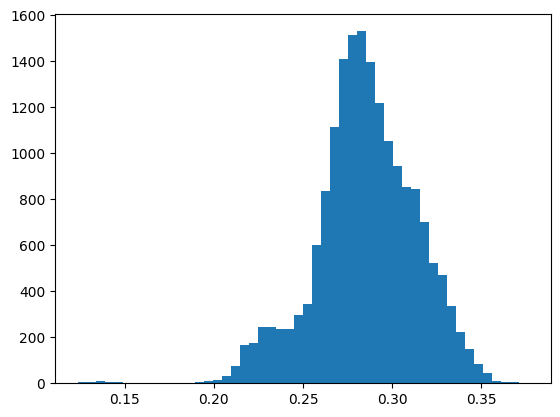

In [24]:
plt.hist(bl_rd_ratio_means, bins=50)

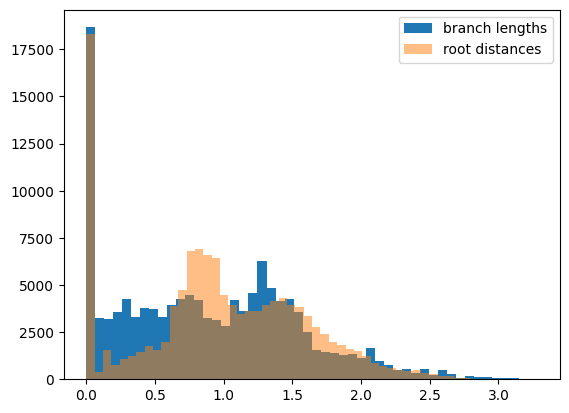

In [35]:
import numpy as np
import torch

fig, axes  = plt.subplots()

axes.hist(torch.concat(y_train_bl).numpy(), label = "branch lengths", bins = 50,)
axes.hist(torch.concat(y_train_rd).numpy() * 0.6, label = "root distances", bins = 50, alpha = 0.5)
plt.legend()